<a href="https://colab.research.google.com/github/rafathaurnab/Data_Science_project/blob/main/new_one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

output_file_path = "/content/drive/MyDrive/Colab Notebooks/ma.csv"
df_cleaned = pd.read_csv(output_file_path)




### ***Summary Tables***





In [4]:
import pandas as pd

df_cleaned.columns = [col.lower() for col in df_cleaned.columns]

In [4]:
summary_mode = df_cleaned.groupby('mode', observed=False)['pax_daily'].agg(['mean', 'median']).reset_index()
summary_mode.columns = ['mode', 'mean_pax_daily', 'median_pax_daily']
display(summary_mode)

,mode,mean_pax_daily,median_pax_daily
0,MetroBus,281974.709302,305975.0
1,MetroTrain,458138.139535,458400.0
2,RegionalBus,27079.302326,28950.0
3,RegionalTrain,39932.848837,41100.0
4,Tram,396536.569767,416325.0


In [5]:
summary_day_type = df_cleaned.groupby('day_type', observed=False)['pax_daily'].agg(['mean', 'median']).reset_index()
summary_day_type.columns = ['day_type', 'mean_pax_daily', 'median_pax_daily']
display(summary_day_type)

,day_type,mean_pax_daily,median_pax_daily
0,Normal Weekday,281347.196468,260050.0
1,School Holiday Weekday,238330.967742,195150.0
2,Weekend,146640.473684,122975.0


In [6]:
summary_day_of_week = df_cleaned.groupby('day_of_week', observed=False)['pax_daily'].agg(['mean', 'median']).reset_index()
summary_day_of_week.columns = ['day_of_week', 'mean_pax_daily', 'median_pax_daily']
display(summary_day_of_week)

,day_of_week,mean_pax_daily,median_pax_daily
0,Friday,264025.725191,232100.0
1,Monday,248087.067669,210700.0
2,Saturday,169497.789474,152900.0
3,Sunday,123783.157895,115300.0
4,Thursday,276469.044118,241150.0
5,Tuesday,270939.179104,223250.0
6,Wednesday,277055.220588,240200.0


In [7]:
summary_period = df_cleaned.groupby('period', observed=False)['pax_daily'].agg(['mean', 'median']).reset_index()
summary_period.columns = ['period', 'mean_pax_daily', 'median_pax_daily']
display(summary_period)

,period,mean_pax_daily,median_pax_daily
0,2020–2021,127440.312500,72700.0
1,Post-2021,252513.380952,272625.0
2,Pre-2020,335312.685185,331025.0




# ***Trend Lines***


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_cleaned['monthstart'] = pd.to_datetime(df_cleaned['monthstart'])

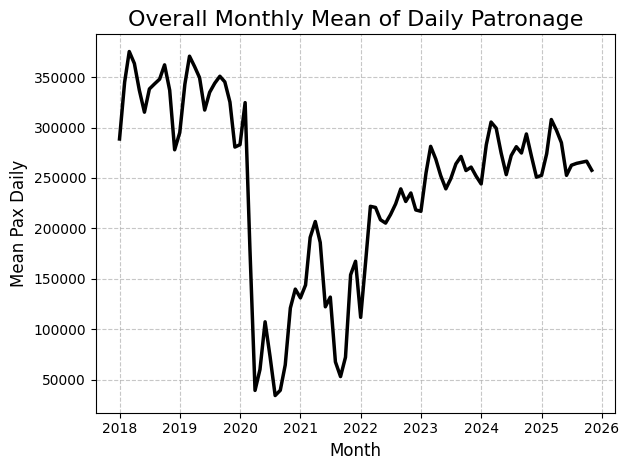

In [9]:
df_overall = df_cleaned.groupby('monthstart')['pax_daily'].mean().reset_index()

sns.lineplot(data=df_overall, x='monthstart', y='pax_daily', color='black', linewidth=2.5)
plt.title('Overall Monthly Mean of Daily Patronage', fontsize=16)
plt.ylabel('Mean Pax Daily', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

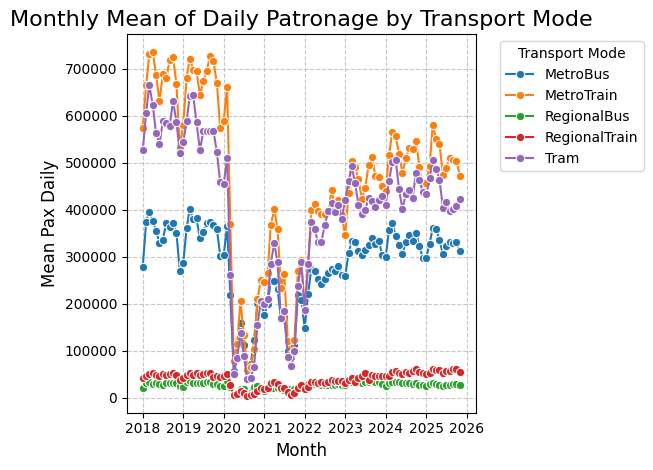

In [10]:
df_mode_trend = df_cleaned.groupby(['monthstart', 'mode'], observed=False)['pax_daily'].mean().reset_index()

sns.lineplot(data=df_mode_trend, x='monthstart', y='pax_daily', hue='mode', marker='o')
plt.title('Monthly Mean of Daily Patronage by Transport Mode', fontsize=16)
plt.ylabel('Mean Pax Daily', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.legend(title='Transport Mode', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# [Seasonality/weekly pattern visuals]


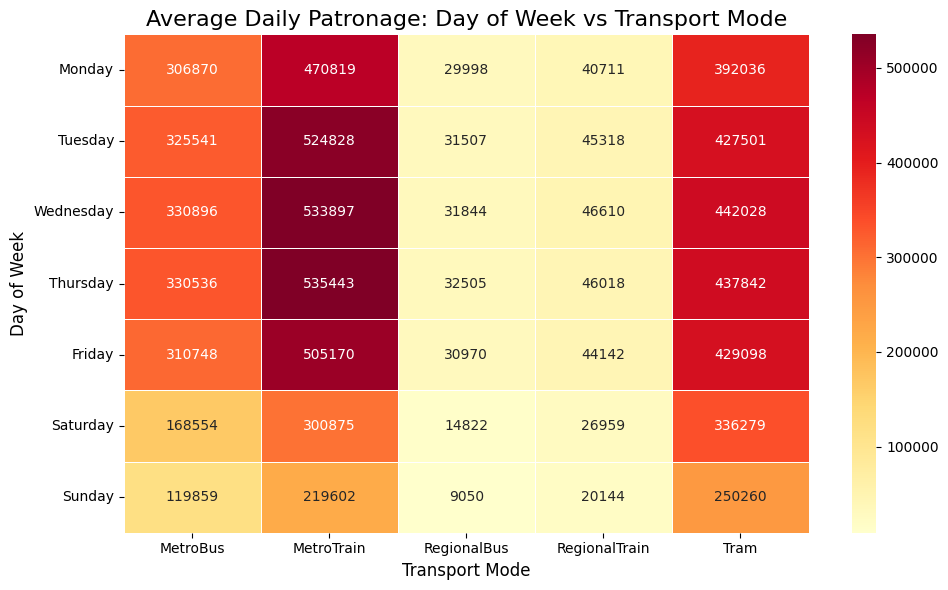

In [11]:
heatmap_data = df_cleaned.groupby(['day_of_week', 'mode'], observed=False)['pax_daily'].mean().unstack()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(day_order)

plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Average Daily Patronage: Day of Week vs Transport Mode', fontsize=16)
plt.ylabel('Day of Week', fontsize=12)
plt.xlabel('Transport Mode', fontsize=12)
plt.tight_layout()
plt.show()


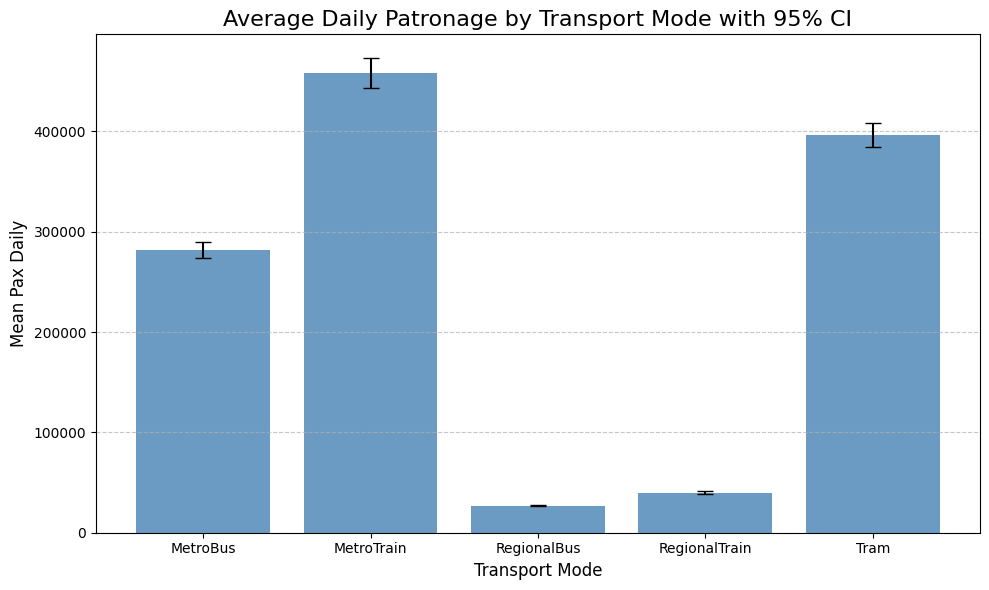

In [12]:
import numpy as np

summary = df_cleaned.groupby('mode', observed=False)['pax_daily'].agg(['mean', 'sem']).reset_index()
summary.columns = ['mode', 'mean_pax_daily', 'sem']
summary['ci95'] = summary['sem'] * 1.96

plt.figure(figsize=(10, 6))
plt.bar(summary['mode'], summary['mean_pax_daily'], yerr=summary['ci95'], capsize=6, color='steelblue', alpha=0.8)
plt.title('Average Daily Patronage by Transport Mode with 95% CI', fontsize=16)
plt.ylabel('Mean Pax Daily', fontsize=12)
plt.xlabel('Transport Mode', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.tight_layout()
plt.show()

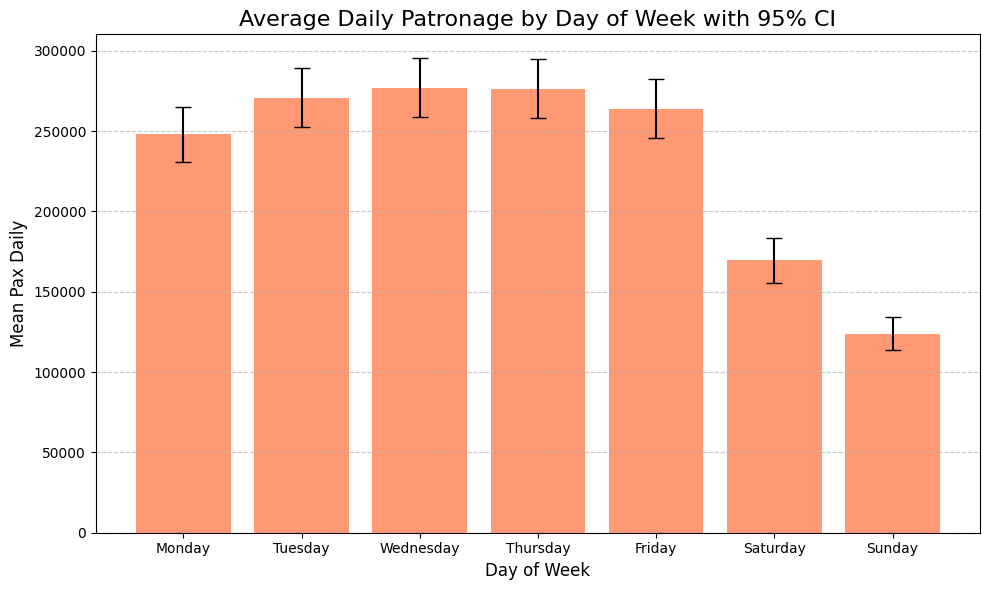

In [13]:
summary_dow = df_cleaned.groupby('day_of_week', observed=False)['pax_daily'].agg(['mean', 'sem']).reset_index()
summary_dow.columns = ['day_of_week', 'mean_pax_daily', 'sem']
summary_dow['ci95'] = summary_dow['sem'] * 1.96

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
summary_dow['day_of_week'] = pd.Categorical(summary_dow['day_of_week'], categories=day_order, ordered=True)
summary_dow = summary_dow.sort_values('day_of_week')

plt.figure(figsize=(10, 6))
plt.bar(summary_dow['day_of_week'], summary_dow['mean_pax_daily'], yerr=summary_dow['ci95'], capsize=6, color='coral', alpha=0.8)
plt.title('Average Daily Patronage by Day of Week with 95% CI', fontsize=16)
plt.ylabel('Mean Pax Daily', fontsize=12)
plt.xlabel('Day of Week', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7, axis='y')
plt.tight_layout()
plt.show()

Histogram diagonastic

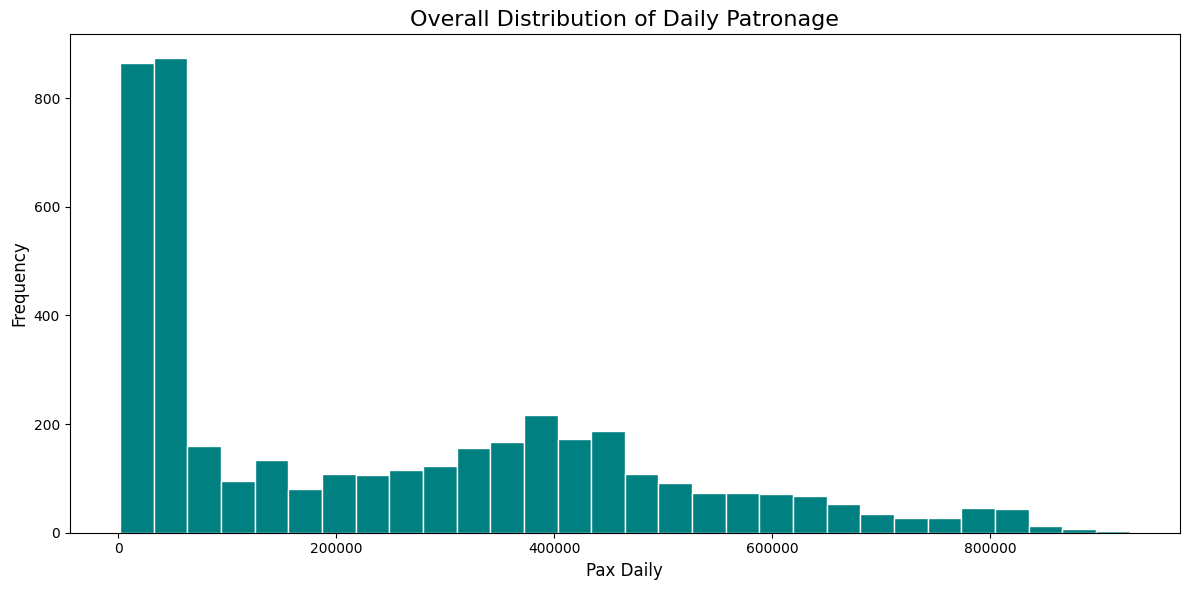

In [14]:
# Overall histogram
df_cleaned['pax_daily'].plot(kind='hist', bins=30, color='teal', edgecolor='white', figsize=(12, 6))
plt.title('Overall Distribution of Daily Patronage', fontsize=16)
plt.xlabel('Pax Daily', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

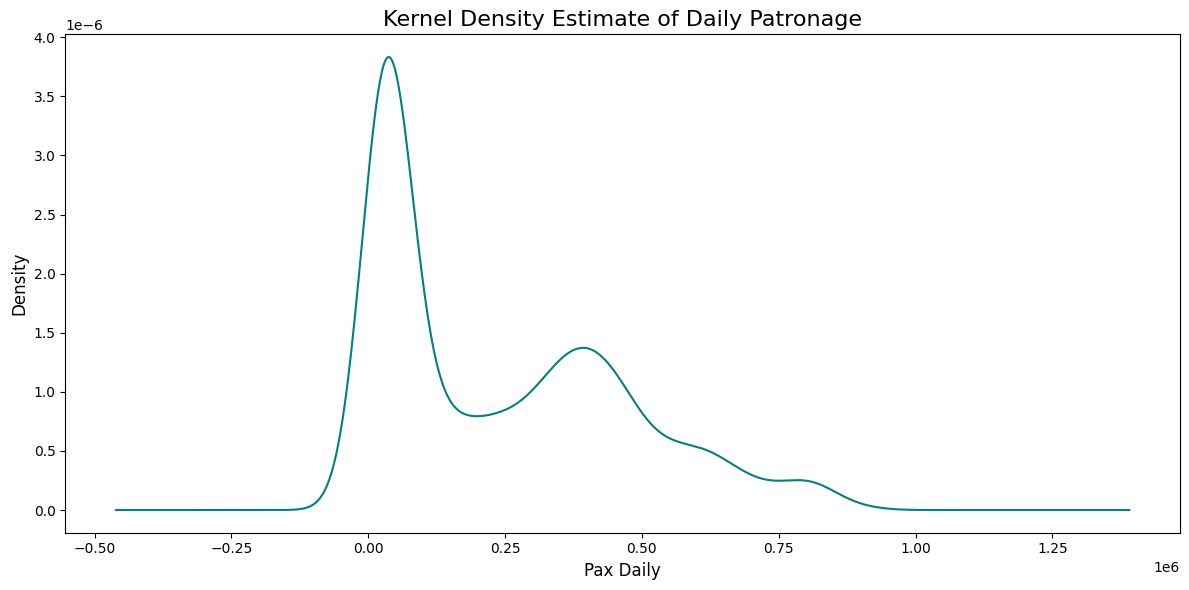

In [15]:
# Overall KDE
df_cleaned['pax_daily'].plot(kind='kde', color='teal', figsize=(12, 6))
plt.title('Kernel Density Estimate of Daily Patronage', fontsize=16)
plt.xlabel('Pax Daily', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.tight_layout()
plt.show()

Histogram per mode

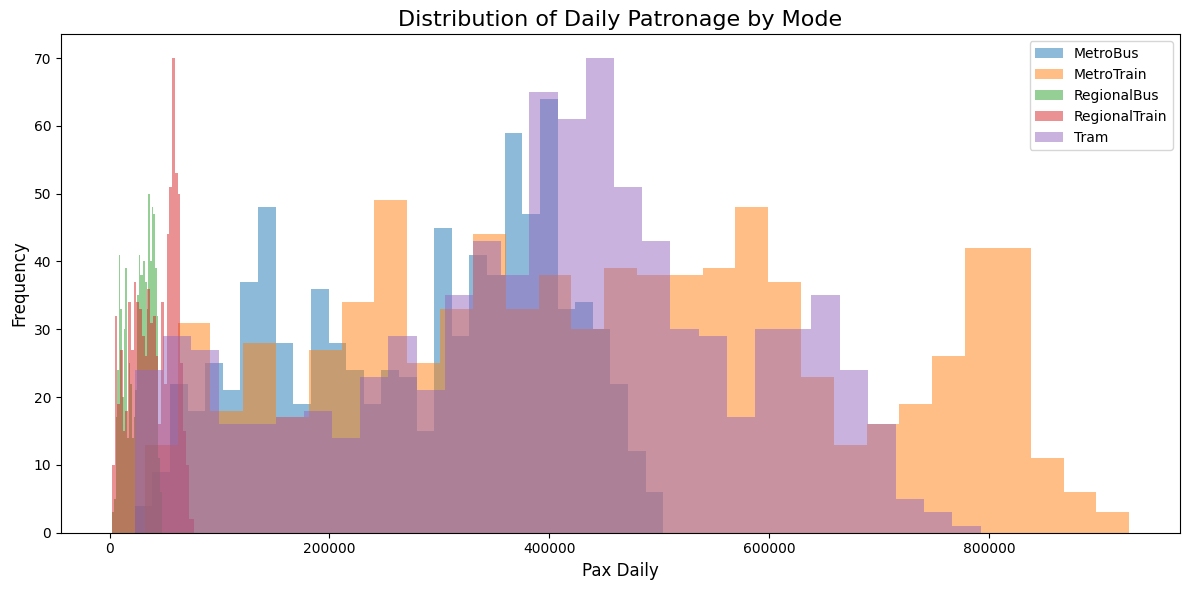

In [16]:
# Histogram per mode
df_cleaned.groupby('mode')['pax_daily'].plot(kind='hist', bins=30, alpha=0.5, legend=True, figsize=(12, 6))
plt.title('Distribution of Daily Patronage by Mode', fontsize=16)
plt.xlabel('Pax Daily', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

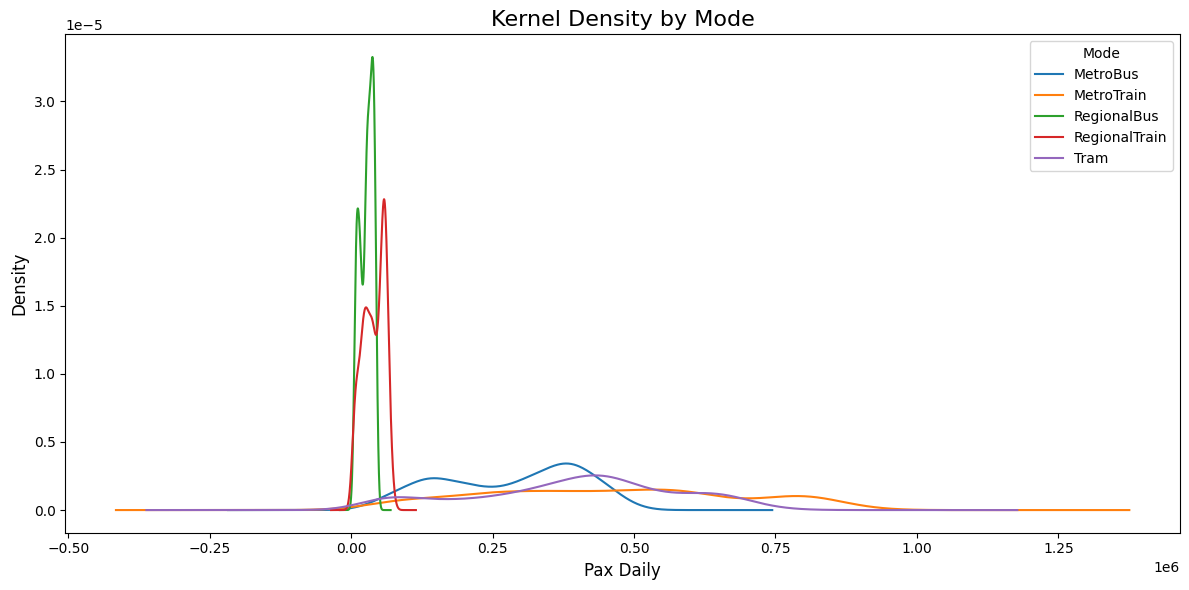

In [17]:
# KDE per mode
df_cleaned.groupby('mode')['pax_daily'].plot(kind='kde', legend=True, figsize=(12, 6))
plt.title('Kernel Density by Mode', fontsize=16)
plt.xlabel('Pax Daily', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Mode')
plt.tight_layout()
plt.show()

In [18]:
for mode_val in modes:
    mode_data = df_cleaned[df_cleaned['mode'] == mode_val]['pax_daily']
    skewness = mode_data.skew()
    print(f"{mode_val}: Skewness = {skewness:.2f}")

MetroBus: Skewness = -0.26
MetroTrain: Skewness = 0.07
RegionalBus: Skewness = -0.31
RegionalTrain: Skewness = -0.25
Tram: Skewness = -0.29


linear regression of pax_daily

In [19]:

df_cleaned['monthstart'] = pd.to_datetime(df_cleaned['monthstart'])
df_cleaned['month_num'] = (
    (df_cleaned['monthstart'].dt.year - df_cleaned['monthstart'].dt.year.min()) * 12 +
    df_cleaned['monthstart'].dt.month
)

# Weekday vs Weekend comparison of Pax_daily per Mode (Mann-Whitney)

We use Mann-Whitney instead of a t-test because the Shapiro-Wilk and Q-Q plots above confirmed that Pax_daily is not normally distributed for any mode. Mann-Whitney does not assume normality — it compares whether one group tends to have higher values than the other. Effect size is measured with Cohen's d (small < 0.5, medium 0.5–0.8, large > 0.8).

In [6]:
import pandas as pd
from scipy.stats import mannwhitneyu
import numpy as np

In [9]:
import numpy as np
from scipy import stats

# 1. Filter subsets for MetroTrain (using correct case for column names)
mt_weekday = df_cleaned[(df_cleaned['mode'] == 'MetroTrain') & (df_cleaned['day_type'] == 'Normal Weekday')]['pax_daily']
mt_weekend = df_cleaned[(df_cleaned['mode'] == 'MetroTrain') & (df_cleaned['day_type'] == 'Weekend')]['pax_daily']

# 2. Check for normality (Shapiro-Wilk)
_, p_norm_wd = stats.shapiro(mt_weekday)
_, p_norm_we = stats.shapiro(mt_weekend)

# Use t-test if both are normal (p > 0.05), else Mann-Whitney U
if p_norm_wd > 0.05 and p_norm_we > 0.05:
    test_name = 'Two-sample T-test'
    t_stat, p_val = stats.ttest_ind(mt_weekday, mt_weekend, equal_var=False)
else:
    test_name = 'Mann-Whitney U test'
    t_stat, p_val = stats.mannwhitneyu(mt_weekday, mt_weekend)

# 3. Calculate 95% Confidence Interval for the difference in means
mean_diff = mt_weekday.mean() - mt_weekend.mean()
n1, n2 = len(mt_weekday), len(mt_weekend)
std1, std2 = mt_weekday.std(), mt_weekend.std()
se = np.sqrt((std1**2 / n1) + (std2**2 / n2))
df_degrees = ((std1**2/n1 + std2**2/n2)**2) / ((std1**2/n1)**2/(n1-1) + (std2**2/n2)**2/(n2-1))
t_crit = stats.t.ppf(0.975, df_degrees)
ci_low, ci_high = mean_diff - t_crit * se, mean_diff + t_crit * se

# 4. Calculate Cohen's d
pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
cohens_d = mean_diff / pooled_std

# 5. Print results
print(f"--- {test_name} Results (MetroTrain) ---")
print(f"Weekday Mean: {mt_weekday.mean():,.2f} | Weekend Mean: {mt_weekend.mean():,.2f}")
print(f"Statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")
print(f"95% CI for difference: ({ci_low:,.2f}, {ci_high:,.2f})")
print(f"Cohen's d: {cohens_d:.4f}")

--- Mann-Whitney U test Results (MetroTrain) ---
Weekday Mean: 541,870.97 | Weekend Mean: 260,238.68
Statistic: 73811.0000
P-value: 1.6538e-46
95% CI for difference: (257,049.51, 306,215.07)
Cohen's d: 1.4609


## Cross-Mode Analysis (ANOVA)

### Subtask:
Conduct a one-way ANOVA or Kruskal-Wallis test to identify significant differences in 'pax_daily' across all transport modes on 'Normal Weekdays', followed by a post-hoc Tukey HSD test if results are significant.


In [11]:
from scipy.stats import shapiro, levene, f_oneway, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Filter for Normal Weekdays
wd_df = df_cleaned[df_cleaned['day_type'] == 'Normal Weekday']

# 2. Group Pax_daily by Mode
modes = wd_df['mode'].unique()
groups = [wd_df[wd_df['mode'] == m]['pax_daily'] for m in modes]

# 3. Test Assumptions
print('--- Assumption Testing ---')
normality_passed = True
for mode, group in zip(modes, groups):
    stat, p = shapiro(group)
    print(f'Shapiro-Wilk ({mode}): p-value = {p:.4e}')
    if p < 0.05: normality_passed = False

stat_lev, p_lev = levene(*groups)
print(f'Levene Test (Variance): p-value = {p_lev:.4e}')

# 4. Perform ANOVA or Kruskal-Wallis
if normality_passed and p_lev > 0.05:
    test_name = 'One-way ANOVA'
    stat_test, p_test = f_oneway(*groups)
else:
    test_name = 'Kruskal-Wallis H-test'
    stat_test, p_test = kruskal(*groups)

print(f'\n--- {test_name} Results ---')
print(f'Statistic: {stat_test:.4f}, P-value: {p_test:.4e}')

# 5. Post-hoc Tukey HSD if significant
if p_test < 0.05:
    print('\n--- Post-hoc Tukey HSD Results ---')
    tukey = pairwise_tukeyhsd(endog=wd_df['pax_daily'], groups=wd_df['mode'], alpha=0.05)
    print(tukey.summary())

--- Assumption Testing ---
Shapiro-Wilk (MetroBus): p-value = 8.5574e-18
Shapiro-Wilk (MetroTrain): p-value = 2.2042e-11
Shapiro-Wilk (RegionalBus): p-value = 5.2107e-18
Shapiro-Wilk (RegionalTrain): p-value = 3.0269e-17
Shapiro-Wilk (Tram): p-value = 2.0830e-12
Levene Test (Variance): p-value = 2.1400e-222

--- Kruskal-Wallis H-test Results ---
Statistic: 1737.7854, P-value: 0.0000e+00

--- Post-hoc Tukey HSD Results ---
              Multiple Comparison of Means - Tukey HSD, FWER=0.05               
    group1        group2      meandiff   p-adj     lower        upper     reject
--------------------------------------------------------------------------------
     MetroBus    MetroTrain  197839.7351    0.0  173031.7772   222647.693   True
     MetroBus   RegionalBus -309403.9735    0.0 -334211.9314 -284596.0156   True
     MetroBus RegionalTrain -298085.2097    0.0 -322893.1676 -273277.2518   True
     MetroBus          Tram   96229.2494    0.0   71421.2916  121037.2073   True
   Metr

## Pre/Post Period Recovery Analysis

### Subtask:
Quantify the recovery of 'MetroTrain' patronage by comparing 'Pre-2020' and 'Post-2021' periods during 'Normal Weekdays'.


In [13]:
import numpy as np
from scipy import stats

# 1. Filter subsets for MetroTrain during Normal Weekdays for both periods
# Using the consistent column names from the kernel state (Mode, Day_type, Period, Pax_daily)
pre_2020 = df_cleaned[(df_cleaned['mode'] == 'MetroTrain') &
                      (df_cleaned['day_type'] == 'Normal Weekday') &
                      (df_cleaned['period'] == 'Pre-2020')]['pax_daily']

post_2021 = df_cleaned[(df_cleaned['mode'] == 'MetroTrain') &
                       (df_cleaned['day_type'] == 'Normal Weekday') &
                       (df_cleaned['period'] == 'Post-2021')]['pax_daily']

# 2. Perform two-sample t-test (Welch's t-test)
t_stat, p_val = stats.ttest_ind(post_2021, pre_2020, equal_var=False)

# 3. Calculate means and mean difference
mean_pre = pre_2020.mean()
mean_post = post_2021.mean()
mean_diff = mean_post - mean_pre

# 4. Calculate 95% Confidence Interval for the difference in means
n1, n2 = len(post_2021), len(pre_2020)
s1, s2 = post_2021.std(), pre_2020.std()

se = np.sqrt((s1**2 / n1) + (s2**2 / n2))
# Degrees of freedom for Welch's t-test
df_welch = ((s1**2/n1 + s2**2/n2)**2) / ((s1**2/n1)**2/(n1-1) + (s2**2/n2)**2/(n2-1))
t_crit = stats.t.ppf(0.975, df_welch)

ci_low = mean_diff - t_crit * se
ci_high = mean_diff + t_crit * se

# 5. Print results
print(f"--- Pre/Post Period Recovery Analysis (MetroTrain - Normal Weekdays) ---")
print(f"Pre-2020 Mean: {mean_pre:,.2f}")
print(f"Post-2021 Mean: {mean_post:,.2f}")
print(f"Mean Difference (Recovery Delta): {mean_diff:,.2f}")
print(f"P-value: {p_val:.4e}")
print(f"95% Confidence Interval for Difference: ({ci_low:,.2f}, {ci_high:,.2f})")
print(f"Recovery Percentage: {(mean_post/mean_pre)*100:.2f}%")

--- Pre/Post Period Recovery Analysis (MetroTrain - Normal Weekdays) ---
Pre-2020 Mean: 804,790.00
Post-2021 Mean: 539,645.74
Mean Difference (Recovery Delta): -265,144.26
P-value: 3.5021e-122
95% Confidence Interval for Difference: (-278,988.79, -251,299.73)
Recovery Percentage: 67.05%
